In [8]:
import sys
sys.path.append('..')   # so we can import from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import get_returns

# Display settings
pd.set_option('display.float_format', '{:.6f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Imports OK")

Imports OK


In [9]:
TICKER = "NVDA"
START = "2020-01-01"

data = get_returns(TICKER, START)
returns = data['log_return']

print(f"Loaded {len(data)} trading days for {TICKER}")
print(f"From {data.index.min().date()} to {data.index.max().date()}")
data.head()

Loaded 1605 trading days for NVDA
From 2020-01-03 to 2026-05-22


Price,close,log_return
2020-01-03,5.875186,-0.016136
2020-01-06,5.899825,0.004185
2020-01-07,5.971252,0.012034
2020-01-08,5.982451,0.001874
2020-01-09,6.048154,0.010923


In [10]:
stats_table = pd.DataFrame({
    'Metric': ['Mean (daily)', 'Std Dev (daily)', 'Annualized Vol',
               'Min', 'Max', 'Skewness', 'Excess Kurtosis',
               'Jarque-Bera p-value'],
    'Value': [
        returns.mean(),
        returns.std(),
        returns.std() * np.sqrt(252),
        returns.min(),
        returns.max(),
        stats.skew(returns),
        stats.kurtosis(returns),
        stats.jarque_bera(returns)[1]
    ]
})

print(stats_table.to_string(index=False))

             Metric     Value
       Mean (daily)  0.002234
    Std Dev (daily)  0.032795
     Annualized Vol  0.520611
                Min -0.203980
                Max  0.218088
           Skewness  0.048357
    Excess Kurtosis  4.119434
Jarque-Bera p-value  0.000000


Observation: NVDA's excess kurtosis is 4.119427 (vs 0 for a normal distribution), indicating extremely fat tails. The Jarque-Bera test rejects normality (p < 0.001). Skewness is near zero (0.048356), meaning extreme moves are roughly symmetric — but it's the magnitude of those extreme moves that the normal distribution fails to capture. Over 2020–2026 NVDA saw single-day moves of -20% and +22% — events a normal distribution would say happen once every 100+ years. Parametric VaR will severely understate tail risk.

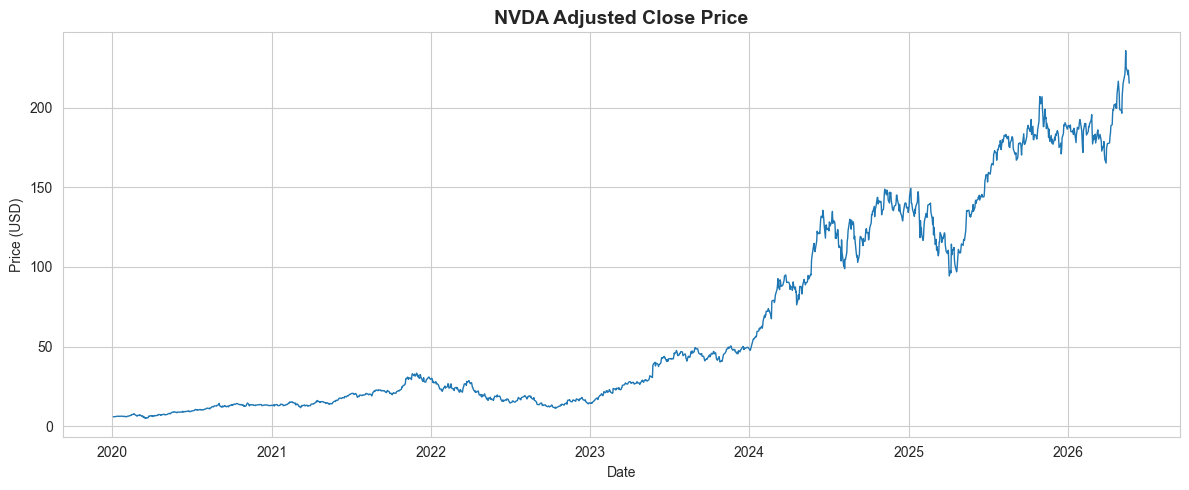

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data['close'], color='#1f77b4', linewidth=1)
ax.set_title(f'{TICKER} Adjusted Close Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.savefig('../outputs/nvda_price.png', dpi=120, bbox_inches='tight')
plt.show()

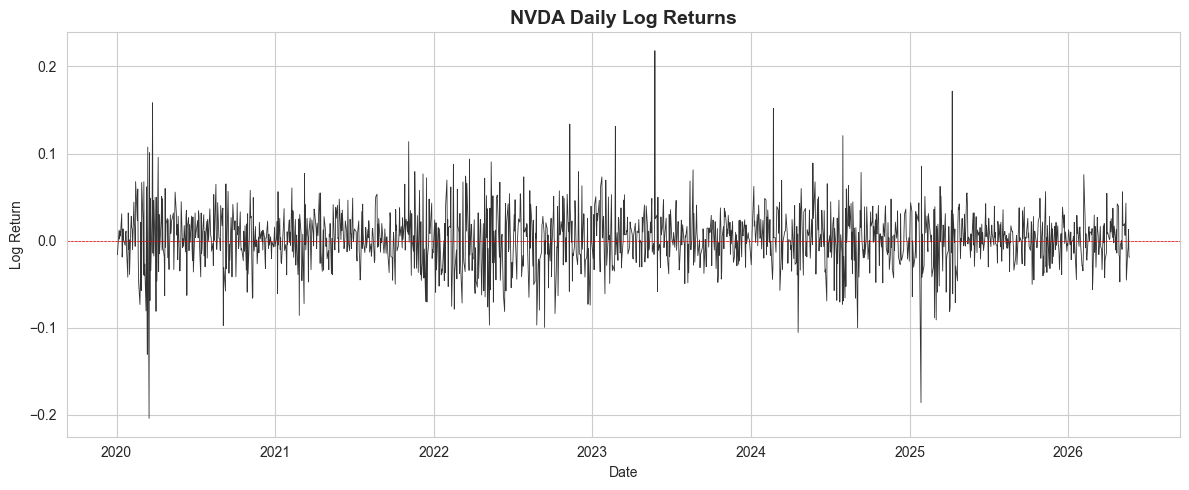

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(returns.index, returns, color='#333', linewidth=0.6)
ax.axhline(0, color='red', linewidth=0.5, linestyle='--')
ax.set_title(f'{TICKER} Daily Log Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
plt.tight_layout()
plt.savefig('../outputs/nvda_returns.png', dpi=120, bbox_inches='tight')
plt.show()

Observation: Volatility is clearly not constant. Three regimes stand out:

Q1 2020: COVID crash — the largest cluster of extreme moves (including the -20% minimum).
2022: Sustained elevated volatility through the rate-hike bear market.
May 2023 & Jan 2025: Single-day shocks (+22% AI earnings beat, -19% DeepSeek selloff) embedded in periods of otherwise normal volatility.

The clustering — where today's volatility predicts tomorrow's — violates the i.i.d. assumption underlying parametric VaR. This is exactly what GARCH(1,1) models in Week 4: time-varying volatility that responds to recent shocks. A static σ estimate (used in basic parametric VaR) treats March 2020 and December 2021 as having the same risk, which is obviously wrong.

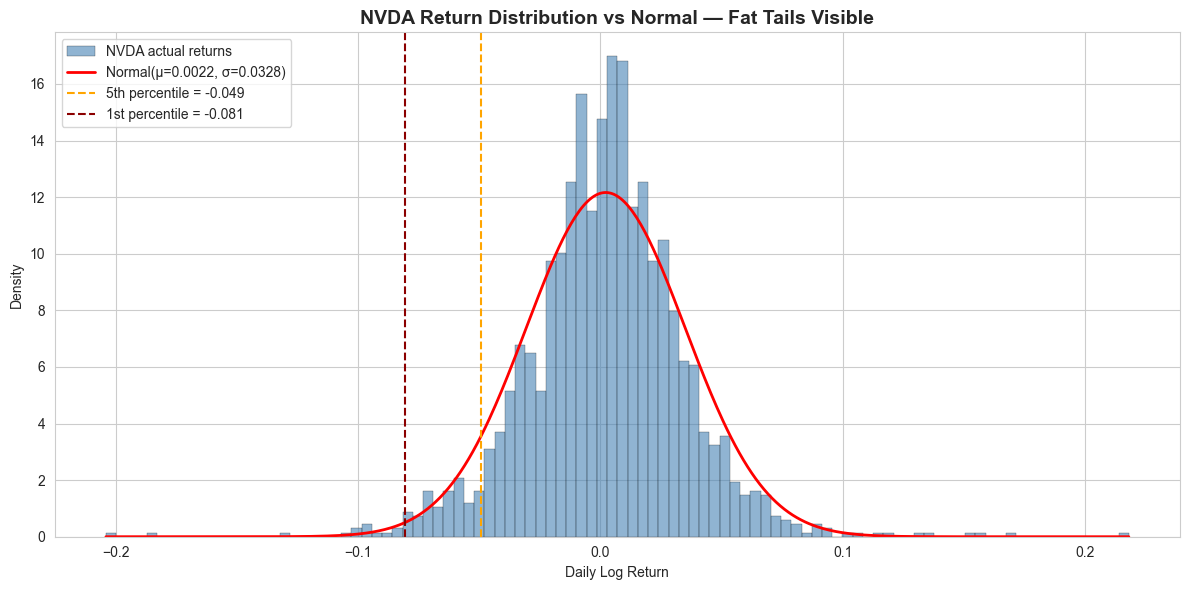

In [13]:
mu, sigma = returns.mean(), returns.std()

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(returns, bins=100, density=True, alpha=0.6,
        color='steelblue', edgecolor='black', linewidth=0.3,
        label='NVDA actual returns')

x = np.linspace(returns.min(), returns.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
        label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')

p5, p1 = np.percentile(returns, [5, 1])
ax.axvline(p5, color='orange', linestyle='--', linewidth=1.5,
           label=f'5th percentile = {p5:.3f}')
ax.axvline(p1, color='darkred', linestyle='--', linewidth=1.5,
           label=f'1st percentile = {p1:.3f}')

ax.set_title(f'{TICKER} Return Distribution vs Normal — Fat Tails Visible',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/nvda_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

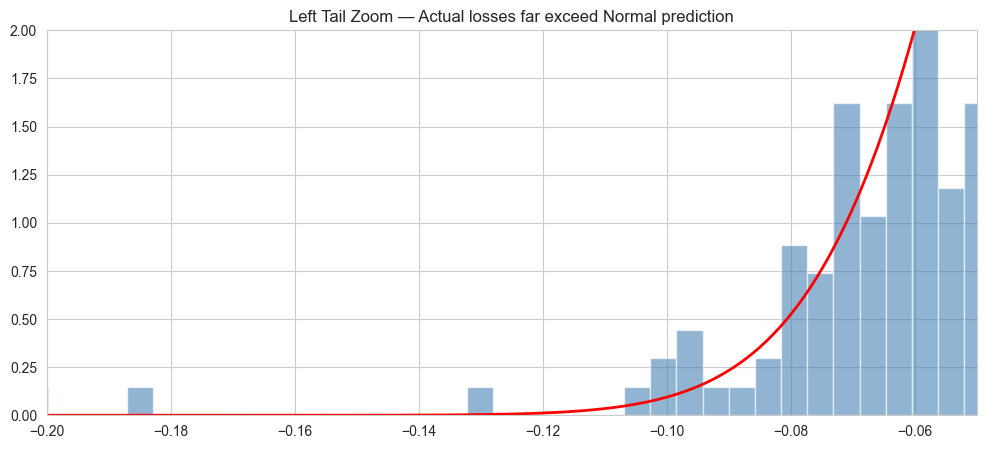

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(returns, bins=100, density=True, alpha=0.6, color='steelblue')
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
ax.set_xlim(-0.20, -0.05)   # zoom on left tail
ax.set_ylim(0, 2)
ax.set_title('Left Tail Zoom — Actual losses far exceed Normal prediction')
plt.savefig('../outputs/nvda_left_tail.png', dpi=120, bbox_inches='tight')
plt.show()

Key Findings — NVDA EDA

1. Returns are non-normal. Excess kurtosis of 4.12 (normal = 0) and Jarque-Bera p ≈ 0 reject normality. Tails are symmetric (skew ≈ 0) but extreme on both sides — single-day moves of -20% and +22% in the sample.
2. Tails are fat. Both left and right tails exceed the normal curve's predictions, meaning extreme moves happen more often than a normal-based model expects.
3. Volatility clusters. Visible regimes of calm and turbulence in the returns plot — violates i.i.d. assumption used in parametric VaR.
4. Implication for VaR: Parametric (normal-based) VaR will underestimate tail risk on NVDA. Historical and Monte Carlo (with Student-t) methods should better capture the fat tails. We will quantify this gap in `02_var_comparison_nvda.ipynb`.